In [1]:
import warnings
warnings.filterwarnings("ignore")

import os
import joblib

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from xgboost import XGBRegressor

from sklearn.model_selection import TimeSeriesSplit

from sklearn.metrics import ( mean_absolute_error, mean_squared_error, r2_score )

In [2]:
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
sns.set_theme(
style="whitegrid",
palette="Set2"
)
plt.rcParams["figure.figsize"] = (12,6)
plt.rcParams["figure.dpi"] = 120

In [3]:
df = pd.read_csv(
"../data/final/ml_dataset.csv"
)

In [4]:
df.columns = (
df.columns
.str.strip()
.str.lower()
)


In [5]:
df["date"] = pd.to_datetime( df["date"] )
df = df.sort_values("date")

In [6]:
TARGET = "log_cases"

In [7]:
#REMOVE LEAKAGE COLUMNS
REMOVE_COLS = [
"cases",
"log_cases",
"outbreak",
"date",
"id"
]

In [16]:
#FEATURE LIST

FEATURES = [
col
for col in df.columns
if col not in REMOVE_COLS
]

FEATURES = [
col
for col in FEATURES
if pd.api.types.is_numeric_dtype(df[col])
]

print("TOTAL FEATURES")
print(len(FEATURES))

#FEATURE MATRIX

X = df[FEATURES]
X = X.replace( [np.inf, -np.inf], np.nan )
X = X.fillna(0)
y = df[TARGET]
print(X.shape)

TOTAL FEATURES
29
(8984, 29)


In [17]:
#TIME SERIES SPLIT

tscv = TimeSeriesSplit(n_splits=5)

In [18]:
#MODEL
model = XGBRegressor(
n_estimators=500,
learning_rate=0.05,
max_depth=6,
subsample=0.8,
colsample_bytree=0.8,
objective="reg:squarederror",
random_state=RANDOM_STATE
)

In [19]:
#TRAINING LOOP

fold_results = []
all_preds = []
all_actuals = []

for fold, (train_idx, test_idx) in enumerate( tscv.split(X), start=1 ):
    X_train = X.iloc[train_idx]
    X_test = X.iloc[test_idx]
    y_train = y.iloc[train_idx]
    y_test = y.iloc[test_idx]

model.fit(X_train, y_train)
preds = model.predict(X_test)
all_preds.extend(preds)
all_actuals.extend(y_test)

mae = mean_absolute_error( y_test, preds )
rmse = np.sqrt( mean_squared_error( y_test, preds ))
r2 = r2_score( y_test, preds  )
fold_results.append({
    "fold": fold,
    "mae": mae,
    "rmse": rmse,
    "r2": r2
})

print(f"FOLD {fold}")
print(f"MAE  : {mae:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R2   : {r2:.4f}")

FOLD 5
MAE  : 0.0858
RMSE : 0.1908
R2   : 0.9675


In [20]:
#RESULTS DATAFRAME

results_df = pd.DataFrame( fold_results )
results_df.style.background_gradient( cmap="Blues" )

,fold,mae,rmse,r2
0,5,0.085813,0.190756,0.967492


In [15]:
#AVERAGE METRICS

avg_mae = results_df["mae"].mean()
avg_rmse = results_df["rmse"].mean()
avg_r2 = results_df["r2"].mean()

print("XGBOOST REGRESSION PERFORMANCE")
print(f"Average MAE : {avg_mae:.4f}")
print(f"Average RMSE : {avg_rmse:.4f}")
print(f"Average R2 : {avg_r2:.4f}")

XGBOOST REGRESSION PERFORMANCE
Average MAE : 0.0858
Average RMSE : 0.1908
Average R2 : 0.9675


In [26]:
#PERFORMANCE INTERPRETATION

if avg_r2 < 0:
    print("Poor predictive performance")

elif avg_r2 < 0.3:
    print(" Weak predictive performance")

elif avg_r2 < 0.6:
    print(" Moderate predictive performance")

else:
    print(" Strong predictive performance")


 Strong predictive performance


In [25]:
os.makedirs( "../reports", exist_ok=True )

results_df.to_csv(
"../reports/xgb_regression_metrics.csv",
index=False
)

print("Metrics Saved")

Metrics Saved


In [24]:
#FEATURE IMPORTANCE

importance_df = pd.DataFrame({ "feature": FEATURES, "importance": model.feature_importances_})
importance_df = ( importance_df .sort_values( by="importance",ascending=False ))

top_features = ( importance_df.head(15))

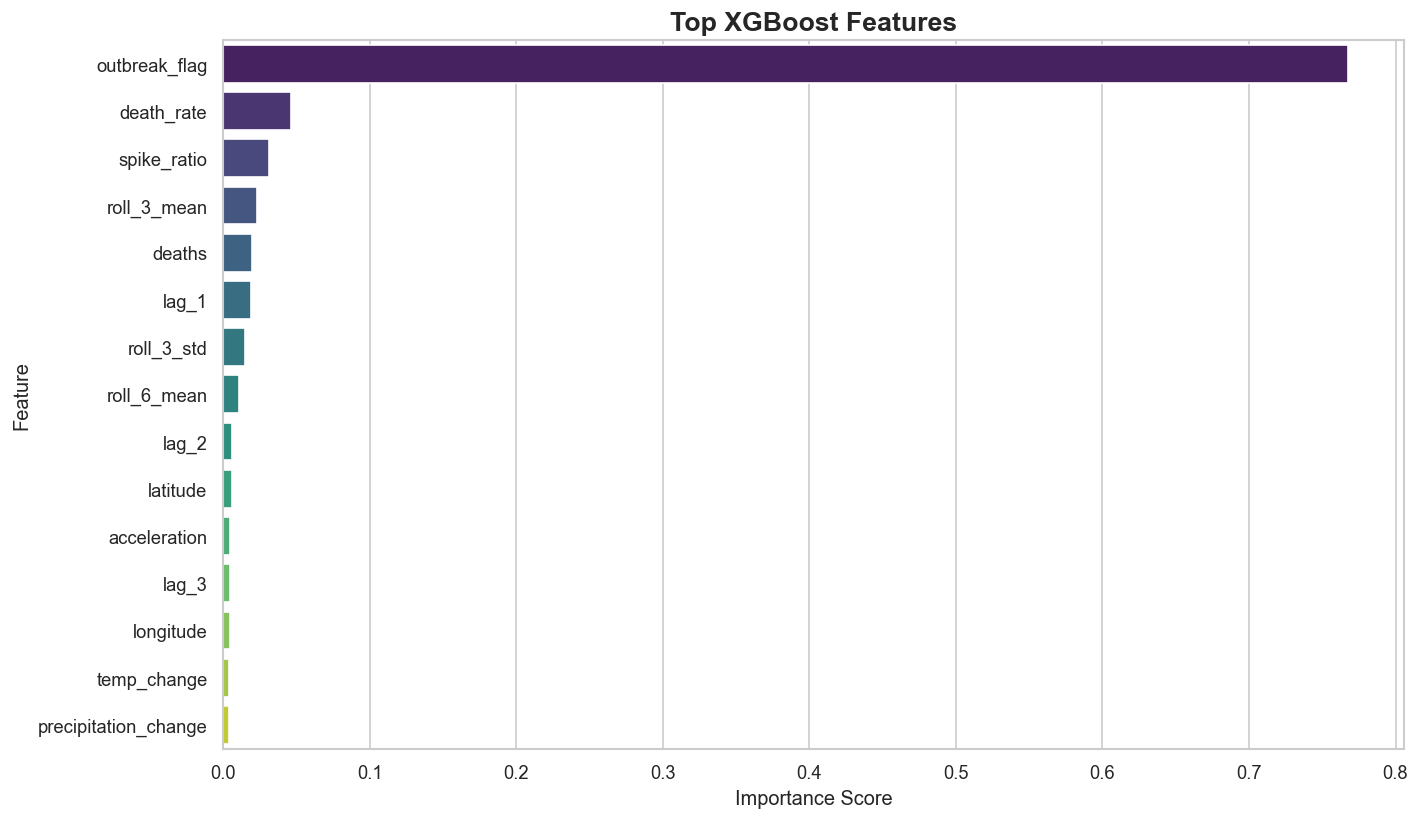

In [27]:
#FEATURE IMPORTANCE PLOT
plt.figure(figsize=(12,7))
sns.barplot(
data=top_features,
x="importance",
y="feature",
palette="viridis"
)

plt.title(
"Top XGBoost Features",
fontsize=16,
fontweight="bold"
)

plt.xlabel("Importance Score")
plt.ylabel("Feature")

plt.tight_layout()

plt.savefig(
"../reports/xgb_feature_importance.png",
bbox_inches="tight"
)
plt.show()

In [28]:
#SAVE FEATURE IMPOSTANCE

importance_df.to_csv(
"../reports/xgb_feature_importance.csv",
index=False
)

print("Feature Importance Saved")

Feature Importance Saved


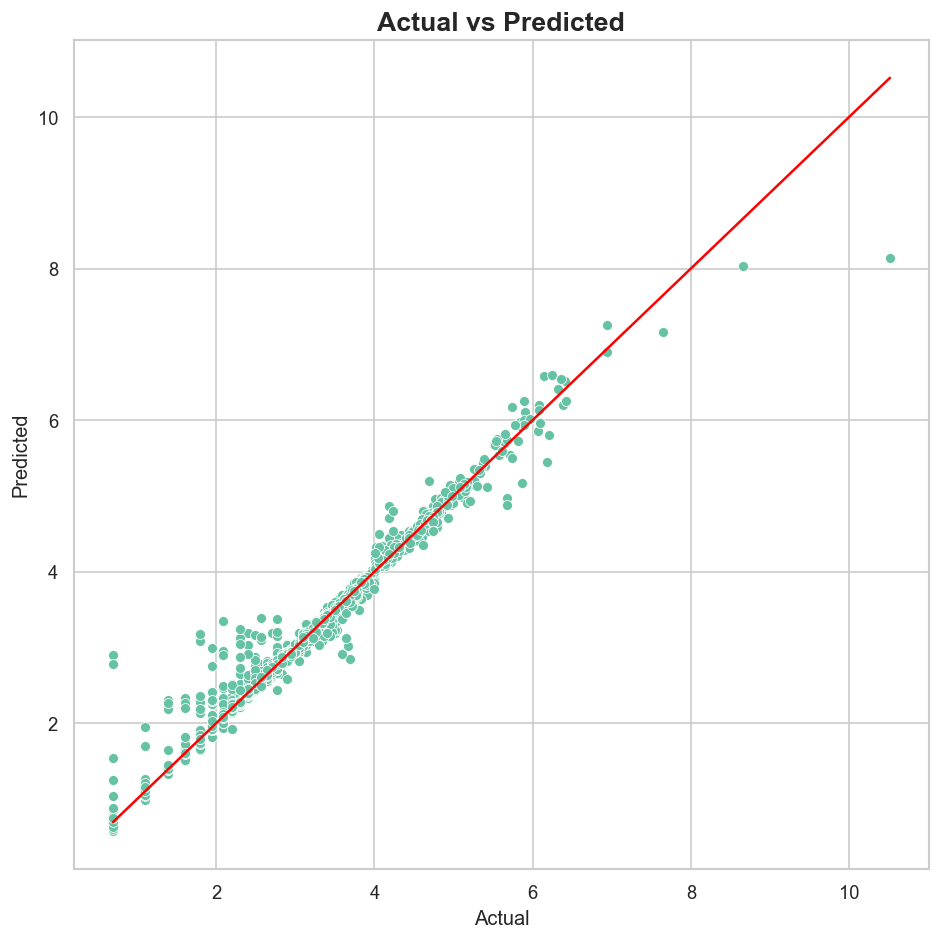

In [29]:
#ACTUAL VS PREDICTED

plt.figure(figsize=(8,8))
sns.scatterplot( x=all_actuals, y=all_preds )

plt.plot(
[min(all_actuals), max(all_actuals)],
[min(all_actuals), max(all_actuals)],
color="red"
)

plt.title(
"Actual vs Predicted",
fontsize=16,
fontweight="bold"
)

plt.xlabel("Actual")
plt.ylabel("Predicted")

plt.tight_layout()

plt.savefig(
"../reports/xgb_actual_vs_predicted.png",
bbox_inches="tight"
)

plt.show()

In [30]:
os.makedirs(
"../artifacts",
exist_ok=True
)

joblib.dump(
model,
"../artifacts/xgb_regressor.pkl"
)

joblib.dump(
FEATURES,
"../artifacts/feature_columns.pkl"
)

print(" Model Artifacts Saved")

 Model Artifacts Saved


In [31]:
os.makedirs(
"../experiments/exp_02_xgb",
exist_ok=True
)

results_df.to_csv(
"../experiments/exp_02_xgb/fold_results.csv",
index=False
)

importance_df.to_csv(
"../experiments/exp_02_xgb/feature_importance.csv",
index=False
)

print("Experiment Saved")

Experiment Saved


In [34]:
summary_df = pd.DataFrame({
"Metric": [
    "Average MAE",
    "Average RMSE",
    "Average R2",
    "Total Features",
    "Total Rows"
],

"Value": [
    round(avg_mae, 4),
    round(avg_rmse, 4),
    round(avg_r2, 4),
    len(FEATURES),
    len(df)
]
})

summary_df.style.background_gradient(cmap="Blues").hide(axis="index")

Metric,Value
Average MAE,0.085800
Average RMSE,0.190800
Average R2,0.967500
Total Features,29.000000
Total Rows,8984.000000
